# Predicting Sales Prices

 ## Dataset Attributes

 The dataset contains information about houses in Ames, Iowa. The data was collected by the Ames City Assessor’s Office describing 2930 property sales which occurred in Ames, Iowa between 2006 and 2010. The dataset, containing 81 variables, was compiled and published by De Cock in 2011.

 Some of the variables contained in the original dataset have been removed from the the dataset provided to you.
 The dataset provided to you contains the following variables:
* **Year_Built:** year that the house was originally constructed
* **Year_Remod_Add:** year that the house was last remodelled
* **Total_Bsmt_SF:** total size of basement area in square feet
* **First_Flr_SF:** size of the first floor in square feet
* **Second_Flr_SF:** size of the second floor in square feet
* **Gr_Liv_Area:** size of above grade, ground living area in square feet
* **Full_Bath:** number of full above grade bathrooms in the house
* **Half_Bath:** number of half above grade bathrooms in the house
* **Bedroom_AbvGr:** number of above grade bedrooms (does not include basement bedrooms)
* **Kitchen_AbvGr:** number of above grade kitchens
* **TotRms_AbvGrd:** total number of above grade rooms (does not include bathrooms)
* **Fireplaces:** number of fireplaces in the house
* **Garage_Area:** size of garage in square feet
* **Sale_Price:** sale price of the house in dollars


*De Cock, D. (2011). "Ames, Iowa: Alternative to the Boston Housing Data as an End of Semester
Regression Project," Journal of Statistics Education, Volume 19, Number 3.*

- https://ww2.amstat.org/publications/jse/v19n3/decock/DataDocumentation.txt
- http://ww2.amstat.org/publications/jse/v19n3/decock.pdf


 ## Objective

 The goal of this task is to analyse the relationship between these variables and build a multiple linear regression model to predict the sales prices based on the 'Gr_Liv_Area' and 'Garage_Area` variables.


In [1]:
# Import libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
# Read in the data set
df = pd.read_csv('ames.csv')
df.head()

,Year_Built,Year_Remod_Add,Total_Bsmt_SF,First_Flr_SF,Second_Flr_SF,Gr_Liv_Area,Full_Bath,Half_Bath,Bedroom_AbvGr,Kitchen_AbvGr,TotRms_AbvGrd,Fireplaces,Garage_Area,Sale_Price
0,1960,1960,1080,1656,0,1656,1,0,3,1,7,2,528,215000
1,1961,1961,882,896,0,896,1,0,2,1,5,0,730,105000
2,1958,1958,1329,1329,0,1329,1,1,3,1,6,0,312,172000
3,1968,1968,2110,2110,0,2110,2,1,3,1,8,2,522,244000
4,1997,1998,928,928,701,1629,2,1,3,1,6,1,482,189900


In [15]:
# Clean and pre-process the data if neccessary
print("Missing values per column:")
print(df.isnull().sum())

df['Garage_Area'] = df['Garage_Area'].fillna(0)

df = df.dropna(subset=['Sale_Price'])

df = df[~((df['Gr_Liv_Area'] > 4000) & (df['Sale_Price'] < 200000))]

print(f"\nDataset shape after cleaning: {df.shape}")


Missing values per column:
Year_Built        0
Year_Remod_Add    0
Total_Bsmt_SF     0
First_Flr_SF      0
Second_Flr_SF     0
Gr_Liv_Area       0
Full_Bath         0
Half_Bath         0
Bedroom_AbvGr     0
Kitchen_AbvGr     0
TotRms_AbvGrd     0
Fireplaces        0
Garage_Area       0
Sale_Price        0
dtype: int64

Dataset shape after cleaning: (2927, 14)


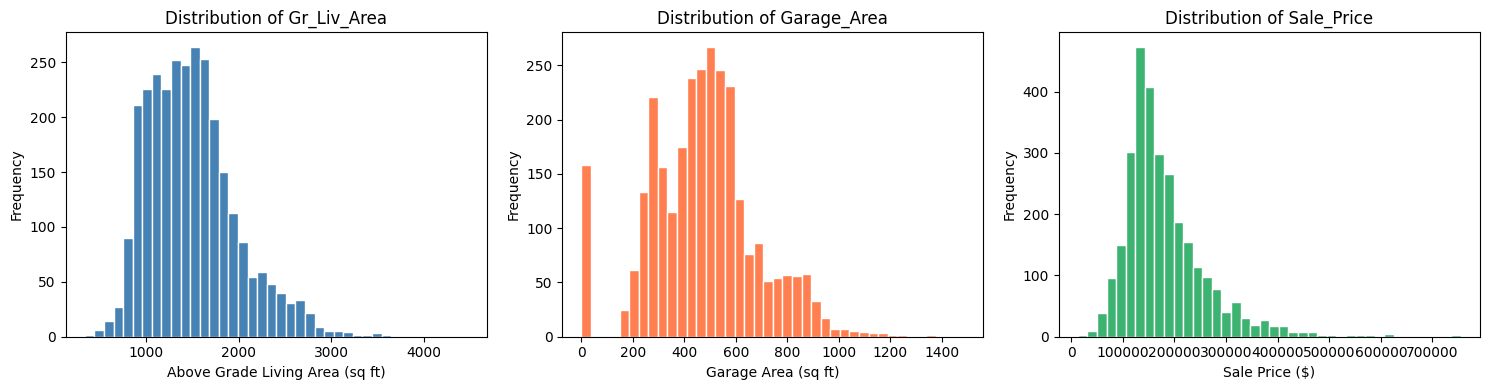

Correlation matrix:
             Gr_Liv_Area  Garage_Area  Sale_Price
Gr_Liv_Area     1.000000     0.475429    0.727122
Garage_Area     0.475429     1.000000    0.644103
Sale_Price      0.727122     0.644103    1.000000


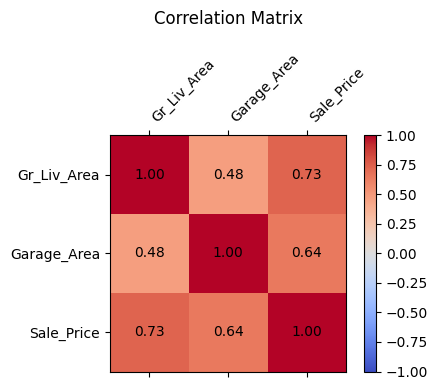

In [ ]:
# Explore the data with visualisations such as histograms and correlation matrices

#Histograms
fig, axes = plt.subplots(1, 3, figsize=(15, 4))  

axes[0].hist(df['Gr_Liv_Area'], bins=40, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of Gr_Liv_Area')
axes[0].set_xlabel('Above Grade Living Area (sq ft)')
axes[0].set_ylabel('Frequency')

axes[1].hist(df['Garage_Area'], bins=40, color='coral', edgecolor='white')
axes[1].set_title('Distribution of Garage_Area')
axes[1].set_xlabel('Garage Area (sq ft)')
axes[1].set_ylabel('Frequency')

axes[2].hist(df['Sale_Price'], bins=40, color='mediumseagreen', edgecolor='white')
axes[2].set_title('Distribution of Sale_Price')
axes[2].set_xlabel('Sale Price ($)')
axes[2].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

#Correlation matrix
corr = df[['Gr_Liv_Area', 'Garage_Area', 'Sale_Price']].corr()
print("Correlation matrix:")
print(corr)

fig, ax = plt.subplots(figsize=(5, 4))
cax = ax.matshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
fig.colorbar(cax)
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha='left')
ax.set_yticklabels(corr.columns)
for (i, j), val in np.ndenumerate(corr.values):
    ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=10)
plt.title('Correlation Matrix', pad=20)
plt.tight_layout()
plt.show()


In [5]:
# Split the independent variables from the dependent variable
X = df[['Gr_Liv_Area', 'Garage_Area']]
y = df['Sale_Price']

print("Independent variables (X):")
print(X.head())
print(f"\nDependent variable (y): Sale_Price")
print(y.head())


Independent variables (X):
   Gr_Liv_Area  Garage_Area
0         1656          528
1          896          730
2         1329          312
3         2110          522
4         1629          482

Dependent variable (y): Sale_Price
0    215000
1    105000
2    172000
3    244000
4    189900
Name: Sale_Price, dtype: int64


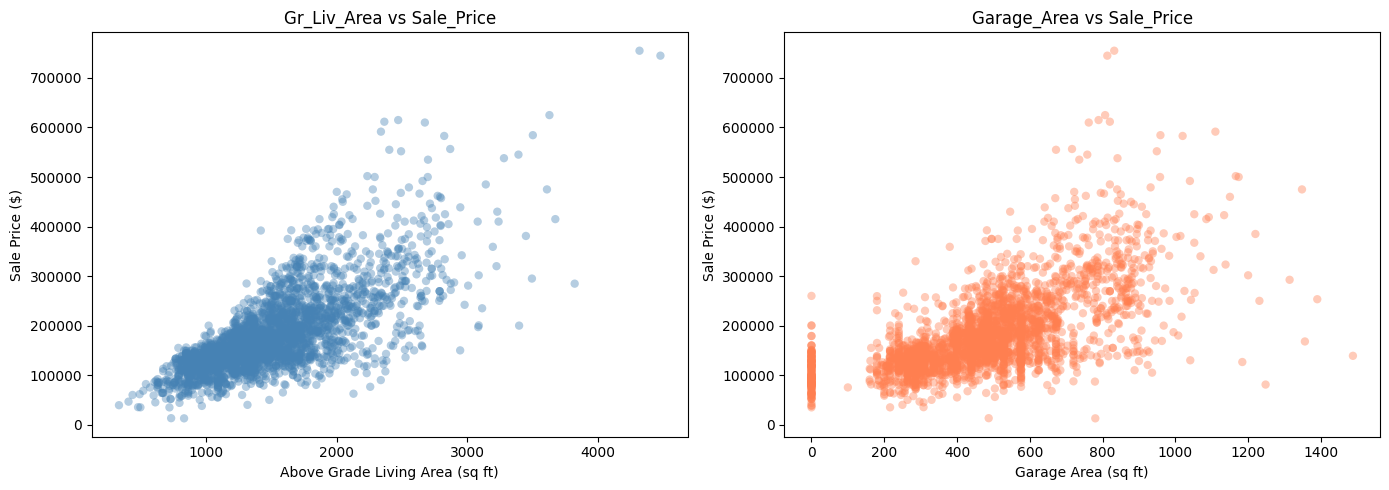

In [6]:
# Generate plots to explore the relationships between the independent and dependent variables
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(df['Gr_Liv_Area'], df['Sale_Price'], alpha=0.4, color='steelblue', edgecolors='none')
axes[0].set_title('Gr_Liv_Area vs Sale_Price')
axes[0].set_xlabel('Above Grade Living Area (sq ft)')
axes[0].set_ylabel('Sale Price ($)')

axes[1].scatter(df['Garage_Area'], df['Sale_Price'], alpha=0.4, color='coral', edgecolors='none')
axes[1].set_title('Garage_Area vs Sale_Price')
axes[1].set_xlabel('Garage Area (sq ft)')
axes[1].set_ylabel('Sale Price ($)')

plt.tight_layout()
plt.show()


In [7]:
# Create a training and test set with a 75:25 split ratio
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size:     {X_test.shape[0]} samples")


Training set size: 2195 samples
Test set size:     732 samples


In [8]:
# Build a multiple linear regression model using 'Gr_Liv_Area' and 'Garage_Area'
model = LinearRegression()
model.fit(X_train, y_train)
print("Model trained successfully.")


Model trained successfully.


In [ ]:
# Print the trained model's intercept and coefficients
print(f"Intercept:               {model.intercept_:,.2f}") #model.intercept_ is the expected mean value of y when all x=0
print(f"Coefficient (Gr_Liv_Area): {model.coef_[0]:,.2f}") #model.coef_[0] is the change in the expected mean value of y for a one unit increase in x1, holding x2 constant
print(f"Coefficient (Garage_Area): {model.coef_[1]:,.2f}") 

Intercept:               -14,610.83
Coefficient (Gr_Liv_Area): 86.18
Coefficient (Garage_Area): 139.27


In [ ]:
# Generate predictions for the test set
y_pred = model.predict(X_test) #y_pred is the predicted values of y for the test set based on the linear regression model
print("First 10 predicted vs actual Sale Prices:")
comparison = pd.DataFrame({'Actual': y_test.values[:10], 'Predicted': y_pred[:10].round(2)}) #comparison is a DataFrame that shows the actual and predicted Sale Prices for the first 10 samples in the test set, with predicted values rounded to 2 decimal places
print(comparison.to_string(index=False))


First 10 predicted vs actual Sale Prices:
 Actual  Predicted
 298236  284872.16
 132000  144038.47
 183500  172527.61
 198444  184610.21
 250000  291252.39
 141000  177019.72
  96000   83378.77
 196000  179084.89
 169000  167861.16
 127000  129559.79


In [11]:
# Evaluate the model's performance by computing the mean squared error (MSE) or root mean squared error (RMSE) on the test set using sklearn.metrics.
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MSE:  {mse:,.2f}")
print(f"RMSE: {rmse:,.2f}")
print(f"R²:   {r2:.4f}")


MSE:  2,474,086,668.92
RMSE: 49,740.19
R²:   0.6691


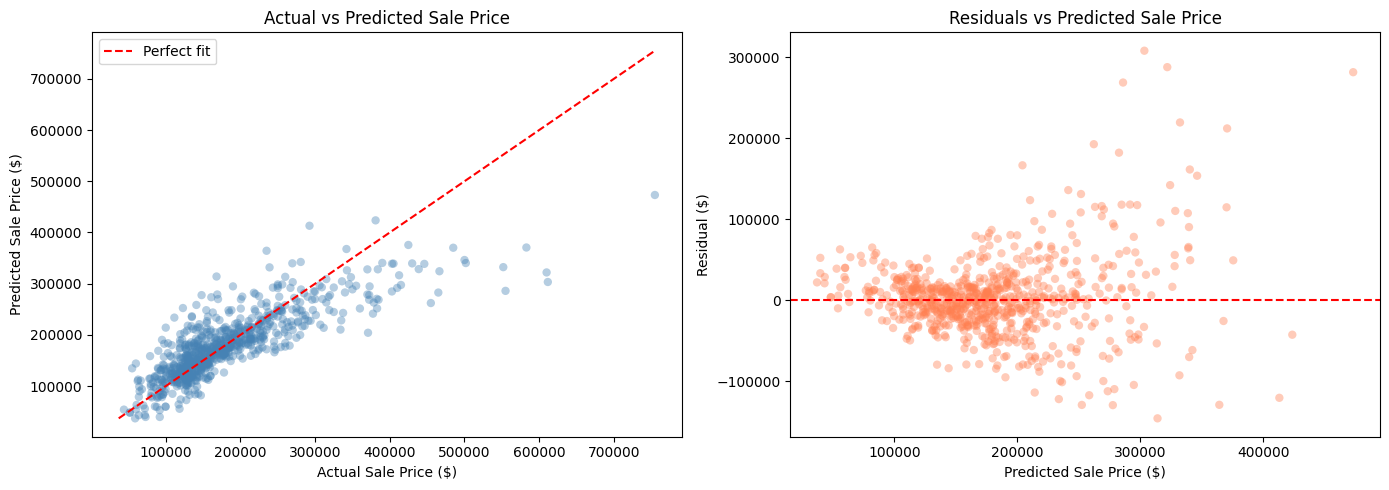

In [12]:
# Generate an error plot to visualise the differences between the predicted and actual values in the test set.
residuals = y_test.values - y_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Actual vs Predicted
axes[0].scatter(y_test, y_pred, alpha=0.4, color='steelblue', edgecolors='none')
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=1.5, label='Perfect fit')
axes[0].set_title('Actual vs Predicted Sale Price')
axes[0].set_xlabel('Actual Sale Price ($)')
axes[0].set_ylabel('Predicted Sale Price ($)')
axes[0].legend()

# Residuals plot
axes[1].scatter(y_pred, residuals, alpha=0.4, color='coral', edgecolors='none')
axes[1].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_title('Residuals vs Predicted Sale Price')
axes[1].set_xlabel('Predicted Sale Price ($)')
axes[1].set_ylabel('Residual ($)')

plt.tight_layout()
plt.show()


In [13]:
# Print the coefficients and interpret them within the context of the median value prediction.
print(f"Intercept:                 ${model.intercept_:,.2f}")
print(f"Coefficient (Gr_Liv_Area): ${model.coef_[0]:,.2f} per sq ft")
print(f"Coefficient (Garage_Area): ${model.coef_[1]:,.2f} per sq ft")


Intercept:                 $-14,610.83
Coefficient (Gr_Liv_Area): $86.18 per sq ft
Coefficient (Garage_Area): $139.27 per sq ft


**Interpret coefficients in the context of the prediction:**

So basically a house starts at $-14,610.83 value. For every sq ft of the Gr_Liv_Area the value goes up by about $86 and it goes up by about $139 for each sq ft of the Garage_Area

So if a house is 2000 sq ft and has a 400 sq ft garage the formula to figure out the value would look like:

Sale_Price = -14,610.83 + (86.18 × 2000) + (139.27 × 400)
           
           = -14,610.83 + 172,360.00 + 55,708.00
           
           = $213,457.17

**Summarise findings**

Throughout this project I found that both the Gr_Liv_Area and Garage_Area have a positive correlation to the price of homes.

The Linear Regression Model Also Gave the Equation to figure out what a home should be Priced at based on the Gr_Liv_Area and Garage_Area.

Sale_Price = -14,610.83 + (86.18 × Gr_Liv_Area) + (139.27 × Garage_Area) With this you can plug in the Area to figure out the sale price

However the Model did get a RMSE of $49,740 and a R2 score of about .67, meaning that it explains about 67% of the Variation in the Price.
The other 33% would come from other Variables not explored like year built, location, room numbers, ect.

I have included more detailed breakdowns to other sections below.

**Histograms**

For the Histograms you can see that there is a pretty noticable trend for each section.

For the Above Grade Living Area it is Right Skewed. You can see how a majority of the homes are betweem that 1000-2000 Sq ft range.

The Garage Area is trimodal. You can see the three peaks at 0, where there are no Garages, around 200, typical size for 1 car garage, and 500, the typical size for the 2 car garage.

The Sales Price is also right skewed but a little stronger then the Grade living area. You can see how it has a longer tail that goes off to the right. Mose of the Houses were priced between the $100,000 and $200,000 range.

**Correlation Map**

For the Correlation Map The Gr_Liv_Area and Sale_Price have the strongest correlation. Which makes sense because the larger the house is typically the higher the sales price is.

The same Can be said for the Garage_Area and Sales_Price just not as Strong as Gr_Liv_Area and Sale_Price. 

The only ones that is Moderate would be Garage_area and Gr_Liv_Area. Typically a larger house will have a bigger Garage but that is not always the case which is why there is the Lower Correlation.

**Sale Price Scatter Plot**

For the Gr_Liv_Area vs Sale_price scatter plot you can see the upward trend as sq ft gets larger so does the sales price. This connects back to the Correlation Map as well.

For the Garage_Area vs Sale_Price you can see one of the three peaks from the trimodal at the 0 point where there are houses with no garages. From there you can still see the upward trend but it is more spread out and not as tight as the Gr_Liv_Area vs Sale_price. This makes sense because it does not have as high of a Correlation.

**RMSE and R2**

With the RMSE at 49,740 that means the model was off about 50k for each of its predictions.

It also has a moderate R2 score. This could probably go up if we had more independent variables to add to the equation.

**Predicted Sale Price Scatter Plot**

For the Actual vs Predicted Sale Price Scatter plot you have the perfect fit line going down the middle there. The Closer the dots are to the line the more accurate the Prediction Model actually was.

For the Residuals vs Predicted Sale Price you can see that the Model was less accurate the higher priced the homes were. It does fan out around 225,000. This shows that there are more factors at play for homes that are priced higher.